## Urban Company Assignment
- By: Vishal Sharma
- Started: April 18, 2025

### Problem Statement
What is a No-response?
- Non-arrival of professionals for their service without prior intimation

### Proposed Solution
- Accelerated prediction of no-response enables the platform to deploy additional strategies to re-assign the booking
- Build a predictive model to predict no-response probability of a request

### Task List
- Perform comprehensive EDA
- Share additional relevant insights and visualisations
- Build a predictive model to predict no-response given the features described
- Find the ideal threshold for prediction if:
    - benefit of a correct no-response prediction is 400
    - benefit of predicting a no-response NOT is 0
    - cost of incorrectly predicting a booking as no-reponse is -200
    - cost of incorrectly predicting a booking as NOT no-response is -500
- Estimate the personalised impact of experiencing an NR on a given request on that customer's LTV

### Confusion Matrix
Actual  Predicted   False       True        </br>
False               TN (0)      FP (-200)   </br>
True                FN (-500)   TP (+400)   </br>

In [1]:
# Standard setup for Kedro + Jupyter integration
import os
from pathlib import Path
from kedro.framework.startup import bootstrap_project
from kedro.framework.session import KedroSession
from kedro.framework.project import configure_project

# 1. Find the project root (assuming notebook is in notebooks/ folder)
project_path = Path.cwd().parent  # Adjust if your notebook is deeper
print(project_path)

# 2. Bootstrap the Kedro project
# if not (project_path / ".kedro.yml").exists():
#     raise ValueError(f"Kedro project not found at {project_path}")

bootstrap_project(project_path)
configure_project(project_path.name)

# 3. Create a session and load the catalog
session = KedroSession.create(project_path=project_path)
context = session.load_context()

# 4. Make catalog available
catalog = context.catalog

[04/19/25 21:32:54] INFO     Using                                                                  ]8;id=729362;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=347706;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/site-packages/kedro/framework/project/__init__.py#270\270]8;;\
                             '/Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/site-packag                
                             es/kedro/framework/project/rich_logging.yml' as logging configuration.                

/Users/vishalsharma/Downloads/urban_company/uc_no_response


                    WARNING  /Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/site-package ]8;id=991499;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/warnings.py\warnings.py]8;;\:]8;id=545075;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/warnings.py#109\109]8;;\
                             s/kedro/io/data_catalog.py:165: KedroDeprecationWarning: `DataCatalog`                
                             has been deprecated and will be replaced by `KedroDataCatalog`, in                    
                             Kedro 1.0.0.Currently some `KedroDataCatalog` APIs have been retained                 
                             for compatibility with `DataCatalog`, including the `datasets`                        
                             property and the `get_datasets`, `_get_datasets`, `add`,` list`,                      
                             `add_feed_dict`, and `shallow_copy` methods. These will be removed or                 
                             replaced with updated alternatives in Kedro 1.0.0. For more details,                  
                             refer to the documentation:                                                           
                             https://docs.kedro.org/en/stable/data/index.html#kedrodatacatalog-expe                
                             rimental-feature                                                                      
                               warnings.warn(                                                                      
                                                                                                                   

[04/19/25 21:32:56] WARNING  /Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/site-package ]8;id=595882;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/warnings.py\warnings.py]8;;\:]8;id=210232;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/warnings.py#109\109]8;;\
                             s/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: [33mAdd                    
                             type hints to the `predict` method to enable data validation and                      
                             automatic signature inference during model logging. Check                             
                             https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage                
                             -in-pythonmodel for more details.[0m                                                  
                               color_warning(                                                                      
                                                                                                                   

                    INFO     Registering new custom resolver: 'km.random_name'                    ]8;id=260818;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/site-packages/kedro_mlflow/framework/hooks/mlflow_hook.py\mlflow_hook.py]8;;\:]8;id=967459;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/site-packages/kedro_mlflow/framework/hooks/mlflow_hook.py#65\65]8;;\

...

                    WARNING  /Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/site-package ]8;id=44947;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/warnings.py\warnings.py]8;;\:]8;id=893051;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/warnings.py#109\109]8;;\
                             s/kedro/io/data_catalog.py:165: KedroDeprecationWarning: `DataCatalog`                
                             has been deprecated and will be replaced by `KedroDataCatalog`, in                    
                             Kedro 1.0.0.Currently some `KedroDataCatalog` APIs have been retained                 
                             for compatibility with `DataCatalog`, including the `datasets`                        
                             property and the `get_datasets`, `_get_datasets`, `add`,` list`,                      
                             `add_feed_dict`, and `shallow_copy` methods. These will be removed or                 
                             replaced with updated alternatives in Kedro 1.0.0. For more details,                  
                             refer to the documentation:                                                           
                             https://docs.kedro.org/en/stable/data/index.html#kedrodatacatalog-expe                
                             rimental-feature                                                                      
                               warnings.warn(                                                                      
                                                                                                                   

[04/19/25 21:32:57] WARNING  /Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/site-package ]8;id=977768;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/warnings.py\warnings.py]8;;\:]8;id=668989;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/warnings.py#109\109]8;;\
                             s/kedro/framework/project/__init__.py:347: UserWarning: The                           
                             'uc_no_response.pipelines.data_processing' module does not expose a                   
                             'create_pipeline' function, so no pipelines defined therein will be                   
                             returned by 'find_pipelines'.                                                         
                               warnings.warn(                                                                      
                                                                                                                   

[04/19/25 21:32:58] WARNING  /Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/site-package ]8;id=118991;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/warnings.py\warnings.py]8;;\:]8;id=27145;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/warnings.py#109\109]8;;\
                             s/kedro/framework/project/__init__.py:347: UserWarning: The                           
                             'uc_no_response.pipelines.modeling' module does not expose a                          
                             'create_pipeline' function, so no pipelines defined therein will be                   
                             returned by 'find_pipelines'.                                                         
                               warnings.warn(                                                                      
                                                                                                                   

                    WARNING  /Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/site-package ]8;id=538161;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/warnings.py\warnings.py]8;;\:]8;id=117484;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/warnings.py#109\109]8;;\
                             s/kedro/framework/project/__init__.py:347: UserWarning: The                           
                             'uc_no_response.pipelines.evaluation' module does not expose a                        
                             'create_pipeline' function, so no pipelines defined therein will be                   
                             returned by 'find_pipelines'.                                                         
                               warnings.warn(                                                                      
                                                                                                                   

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=698707;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/site-packages/kedro_telemetry/plugin.py\plugin.py]8;;\:]8;id=914812;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/site-packages/kedro_telemetry/plugin.py#233\233]8;;\
                             the product. No personal data or IP addresses are stored on our side. If              
                             you want to opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK`              
                             environment variables, or create a `.telemetry` file in the current                   
                             working directory with the contents `consent: false`. Read more at                    
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

In [2]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [36]:
# load the data
df = catalog.load("raw_data")

[04/19/25 22:08:19] INFO     Loading data from raw_data (CSVDataset)...                         ]8;id=200051;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=421648;file:///Users/vishalsharma/miniforge3/envs/uc_env/lib/python3.10/site-packages/kedro/io/data_catalog.py#401\401]8;;\

In [37]:
# shape of the data
df.shape

(20000, 19)

In [38]:
# first 2 rows
df.head(2)

,Unnamed: 0,NR_experienced_on_request,no_of_supercats_tried_last_30d,no_of_supercats_tried_last_90d,no_of_supercats_tried_last_365d,no_of_deliveries_last_30d,no_of_deliveries_last_90d,no_of_deliveries_last_365d,service_deliverd_aov_last_30d,service_deliverd_aov_last_90d,service_deliverd_aov_last_365d,most_deliverd_supercat,income_segment,gender,user_state_platform,days_on_platform,NR_experienced_last_365d,revenues_next_6_months,request_id
0,54458,1,0.0,0.0,2.0,0.0,0.0,4.0,NaN,NaN,691.750000,SKBC,NaN,Male,DORMANT,981.0,0.0,2953.0,8623dfd9-8ff9-4f95-8bf6-8a2889d2bb72
1,118646,0,2.0,4.0,5.0,3.0,5.0,15.0,3514.666667,2297.8,1564.466667,Salon at Home,10 lac - 15lac,Male,ENGAGED,230.0,0.0,4369.0,e0b13106-6573-4677-b0e1-68048af871d9


In [39]:
# data type of all columns
df.dtypes


Unnamed: 0                           int64
NR_experienced_on_request            int64
no_of_supercats_tried_last_30d     float64
no_of_supercats_tried_last_90d     float64
no_of_supercats_tried_last_365d    float64
no_of_deliveries_last_30d          float64
no_of_deliveries_last_90d          float64
no_of_deliveries_last_365d         float64
service_deliverd_aov_last_30d      float64
service_deliverd_aov_last_90d      float64
service_deliverd_aov_last_365d     float64
most_deliverd_supercat              object
income_segment                      object
gender                              object
user_state_platform                 object
days_on_platform                   float64
NR_experienced_last_365d           float64
revenues_next_6_months             float64
request_id                          object
dtype: object

In [40]:
# describe all numerical rows
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,20000.0,100253.179450,57842.563769,5.0,49897.50,100619.50,150375.250000,199985.0
NR_experienced_on_request,20000.0,0.497300,0.500005,0.0,0.00,0.00,1.000000,1.0
no_of_supercats_tried_last_30d,16985.0,0.726641,0.943524,0.0,0.00,0.00,1.000000,7.0
no_of_supercats_tried_last_90d,16985.0,1.410009,1.308526,0.0,0.00,1.00,2.000000,10.0
no_of_supercats_tried_last_365d,16985.0,2.645334,1.879456,0.0,1.00,2.00,4.000000,12.0
no_of_deliveries_last_30d,16985.0,1.039741,2.531830,0.0,0.00,0.00,1.000000,81.0
no_of_deliveries_last_90d,16985.0,2.614954,5.102908,0.0,0.00,1.00,3.000000,178.0
no_of_deliveries_last_365d,16985.0,7.724934,10.512606,0.0,2.00,5.00,10.000000,337.0
service_deliverd_aov_last_30d,8218.0,1080.587791,1093.524138,0.0,498.00,830.75,1348.000000,33607.0
service_deliverd_aov_last_90d,12554.0,1067.201915,1079.056016,0.0,540.75,858.00,1311.553571,43592.0


In [41]:
# check for null 
df.isnull().sum() * 100 / len(df)


Unnamed: 0                          0.000
NR_experienced_on_request           0.000
no_of_supercats_tried_last_30d     15.075
no_of_supercats_tried_last_90d     15.075
no_of_supercats_tried_last_365d    15.075
no_of_deliveries_last_30d          15.075
no_of_deliveries_last_90d          15.075
no_of_deliveries_last_365d         15.075
service_deliverd_aov_last_30d      58.910
service_deliverd_aov_last_90d      37.230
service_deliverd_aov_last_365d     20.735
most_deliverd_supercat             15.075
income_segment                     75.295
gender                              0.085
user_state_platform                15.075
days_on_platform                   15.075
NR_experienced_last_365d            0.085
revenues_next_6_months              7.610
request_id                          0.000
dtype: float64

In [48]:
threshold = 0.7 * len(df.columns)

# Drop rows where more than 80% of features are NULL
df_cleaned = df.dropna(thresh=len(df.columns) - threshold + 1)

In [49]:
df_cleaned.shape

(17377, 19)

In [50]:
df_cleaned.isnull().sum() * 100 / len(df_cleaned)


Unnamed: 0                          0.000000
NR_experienced_on_request           0.000000
no_of_supercats_tried_last_30d      2.255855
no_of_supercats_tried_last_90d      2.255855
no_of_supercats_tried_last_365d     2.255855
no_of_deliveries_last_30d           2.255855
no_of_deliveries_last_90d           2.255855
no_of_deliveries_last_365d          2.255855
service_deliverd_aov_last_30d      52.707602
service_deliverd_aov_last_90d      27.755079
service_deliverd_aov_last_365d      8.770214
most_deliverd_supercat              2.255855
income_segment                     71.565863
gender                              0.000000
user_state_platform                 2.255855
days_on_platform                    2.255855
NR_experienced_last_365d            0.000000
revenues_next_6_months              5.277090
request_id                          0.000000
dtype: float64

In [54]:
df_cleaned[['request_id', 
            'service_deliverd_aov_last_30d', 'no_of_deliveries_last_30d', 
            'service_deliverd_aov_last_90d', 'no_of_deliveries_last_90d', 
            'service_deliverd_aov_last_365d', 'no_of_deliveries_last_365d', 
            ]].sample(5)

,request_id,service_deliverd_aov_last_30d,no_of_deliveries_last_30d,service_deliverd_aov_last_90d,no_of_deliveries_last_90d,service_deliverd_aov_last_365d,no_of_deliveries_last_365d
13163,a232f31d-55f3-4fd9-8b37-9bdf715c8c31,NaN,0.0,NaN,0.0,NaN,0.0
17994,29960da5-fef4-45ca-b86f-eef82ed9b793,NaN,0.0,NaN,0.0,1148.000000,1.0
448,f5073db7-7e59-4b9b-ad82-7aa556596e54,278.0,1.0,672.5,4.0,765.700000,10.0
1304,bea143ae-e4dc-4f4e-8a88-c4f8e8ceeaab,NaN,0.0,598.0,1.0,598.000000,1.0
9937,1465003f-e697-4466-a02f-3937d6c79a61,1542.5,2.0,1192.0,6.0,919.571429,28.0


In [55]:
df_cleaned.loc[df_cleaned['no_of_deliveries_last_30d'] == 0, 'service_deliverd_aov_last_30d'] = 0
df_cleaned.loc[df_cleaned['no_of_deliveries_last_90d'] == 0, 'service_deliverd_aov_last_90d'] = 0
df_cleaned.loc[df_cleaned['no_of_deliveries_last_365d'] == 0, 'service_deliverd_aov_last_365d'] = 0

In [56]:
df_cleaned.isnull().sum() * 100 / len(df_cleaned)


Unnamed: 0                          0.000000
NR_experienced_on_request           0.000000
no_of_supercats_tried_last_30d      2.255855
no_of_supercats_tried_last_90d      2.255855
no_of_supercats_tried_last_365d     2.255855
no_of_deliveries_last_30d           2.255855
no_of_deliveries_last_90d           2.255855
no_of_deliveries_last_365d          2.255855
service_deliverd_aov_last_30d       2.255855
service_deliverd_aov_last_90d       2.255855
service_deliverd_aov_last_365d      2.255855
most_deliverd_supercat              2.255855
income_segment                     71.565863
gender                              0.000000
user_state_platform                 2.255855
days_on_platform                    2.255855
NR_experienced_last_365d            0.000000
revenues_next_6_months              5.277090
request_id                          0.000000
dtype: float64

In [59]:
df_cleaned[df_cleaned['no_of_supercats_tried_last_30d'].isnull()][['no_of_supercats_tried_last_30d', 'no_of_supercats_tried_last_90d', 'no_of_supercats_tried_last_365d']]

,no_of_supercats_tried_last_30d,no_of_supercats_tried_last_90d,no_of_supercats_tried_last_365d
56,NaN,NaN,NaN
68,NaN,NaN,NaN
109,NaN,NaN,NaN
115,NaN,NaN,NaN
126,NaN,NaN,NaN
...,...,...,...
19534,NaN,NaN,NaN
19815,NaN,NaN,NaN
19951,NaN,NaN,NaN
19989,NaN,NaN,NaN


In [60]:
coexisting_nulls = [
    'no_of_supercats_tried_last_30d', 'no_of_supercats_tried_last_90d', 'no_of_supercats_tried_last_365d',
    'no_of_deliveries_last_30d', 'no_of_deliveries_last_90d', 'no_of_deliveries_last_365d',
    'service_deliverd_aov_last_30d', 'service_deliverd_aov_last_90d', 'service_deliverd_aov_last_365d'
]
df_cleaned.dropna(inplace=True, subset=coexisting_nulls)

In [61]:
df_cleaned.isnull().sum() * 100 / len(df_cleaned)


Unnamed: 0                          0.000000
NR_experienced_on_request           0.000000
no_of_supercats_tried_last_30d      0.000000
no_of_supercats_tried_last_90d      0.000000
no_of_supercats_tried_last_365d     0.000000
no_of_deliveries_last_30d           0.000000
no_of_deliveries_last_90d           0.000000
no_of_deliveries_last_365d          0.000000
service_deliverd_aov_last_30d       0.000000
service_deliverd_aov_last_90d       0.000000
service_deliverd_aov_last_365d      0.000000
most_deliverd_supercat              0.000000
income_segment                     73.217545
gender                              0.000000
user_state_platform                 0.000000
days_on_platform                    0.000000
NR_experienced_last_365d            0.000000
revenues_next_6_months              5.398881
request_id                          0.000000
dtype: float64

In [62]:
df_cleaned["NR_experienced_on_request"].value_counts()


NR_experienced_on_request
0    8721
1    8264
Name: count, dtype: int64

In [21]:
# duplicates in user ID?
df['Unnamed: 0'].value_counts()[lambda x: x > 1]

Series([], Name: count, dtype: int64)

In [22]:
# duplicates in request ID?
df['request_id'].value_counts()[lambda x: x > 1]

Series([], Name: count, dtype: int64)

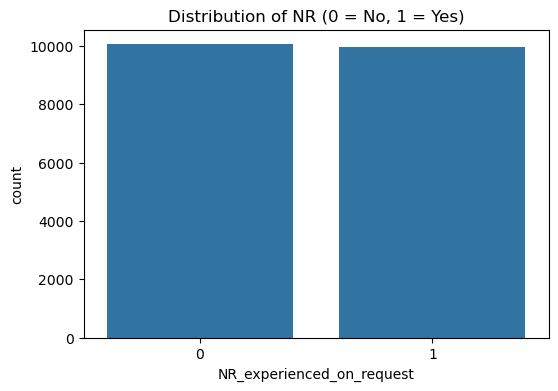

In [11]:
# check for class imbalance
# Plot NR distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='NR_experienced_on_request', data=df)
plt.title("Distribution of NR (0 = No, 1 = Yes)")
plt.show()

Index(['most_deliverd_supercat', 'income_segment', 'gender',
       'user_state_platform', 'request_id'],
      dtype='object')


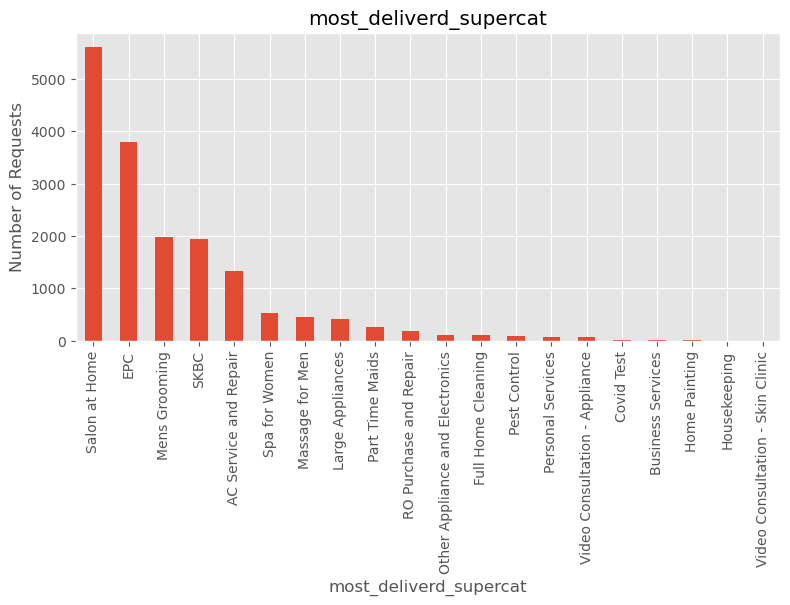

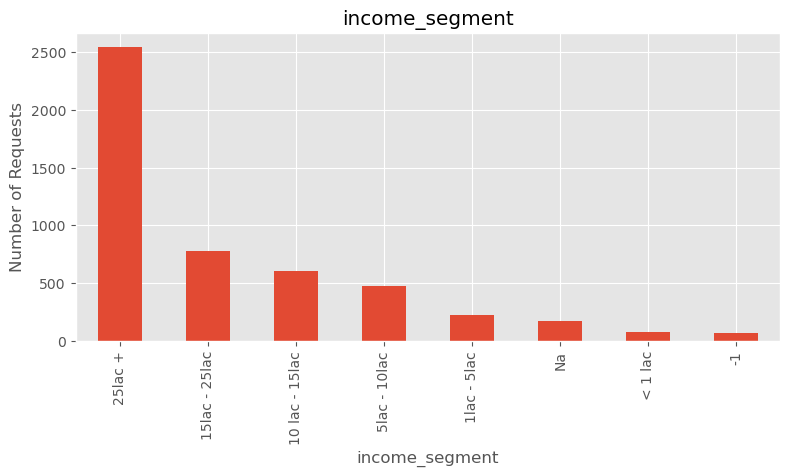

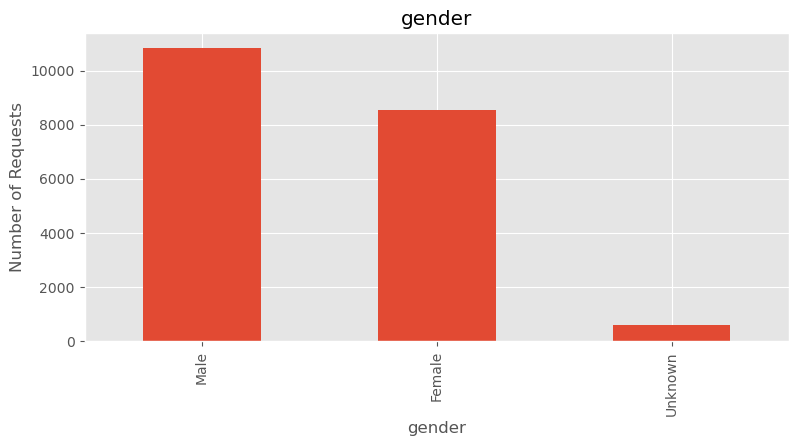

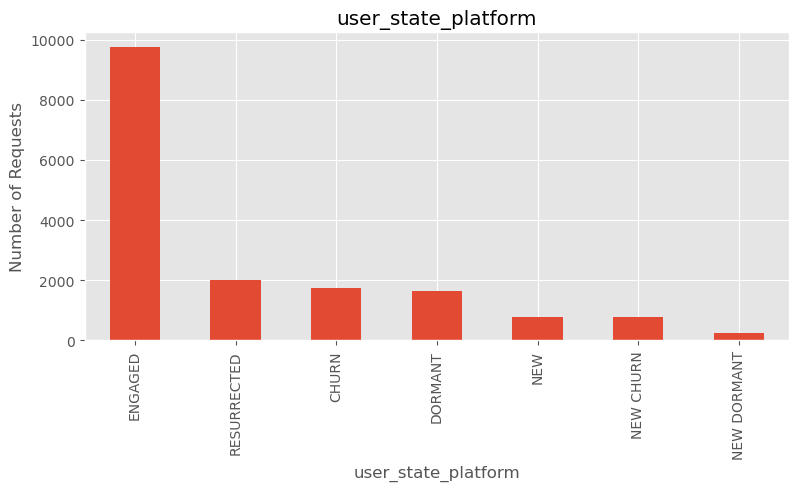

In [12]:
# indentifying the categorical variables
cat_var= df.select_dtypes(include= ["object"]).columns
print(cat_var)

# plotting bar chart for each categorical variable
plt.style.use("ggplot")

for column in cat_var:
    if column not in ['request_id']:
        plt.figure(figsize=(20,4))
        plt.subplot(121)
        df[column].value_counts().plot(kind="bar")
        plt.xlabel(column)
        plt.ylabel("Number of Requests")
        plt.title(column)

<Figure size 2000x400 with 0 Axes>

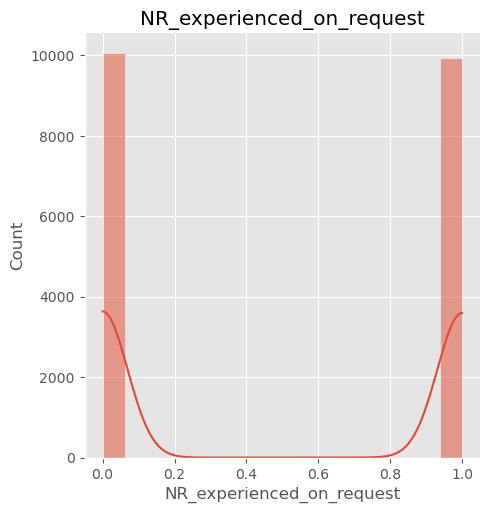

<Figure size 2000x400 with 0 Axes>

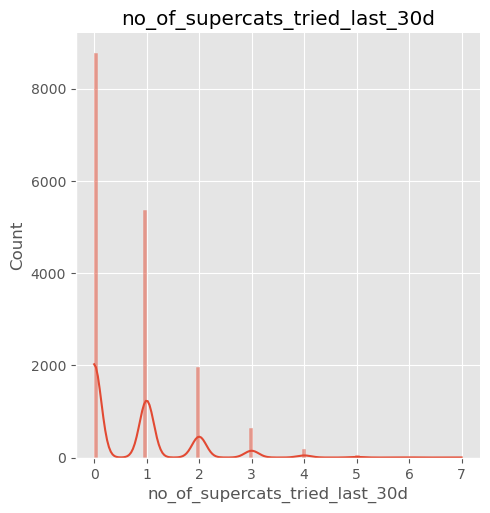

<Figure size 2000x400 with 0 Axes>

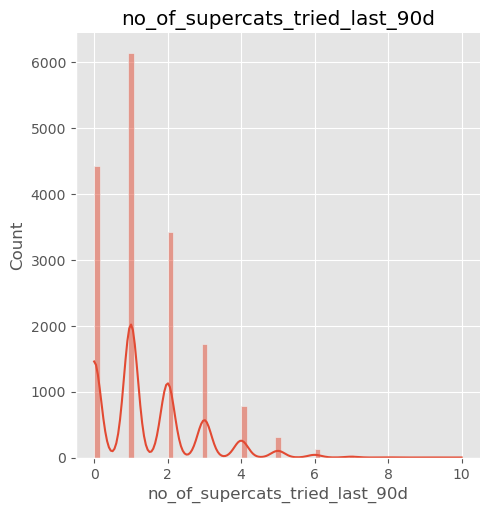

<Figure size 2000x400 with 0 Axes>

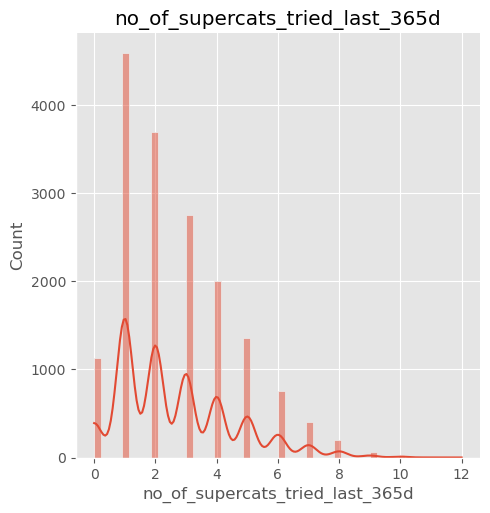

<Figure size 2000x400 with 0 Axes>

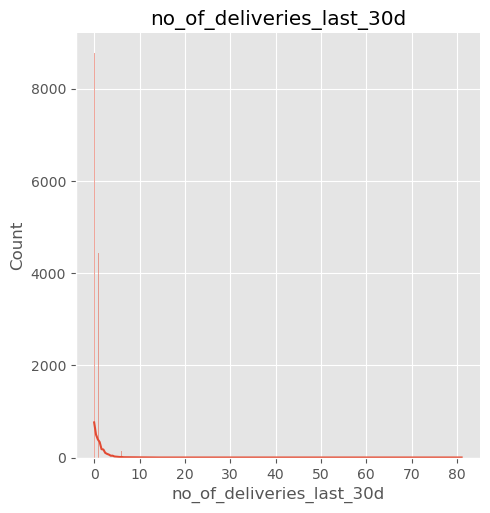

<Figure size 2000x400 with 0 Axes>

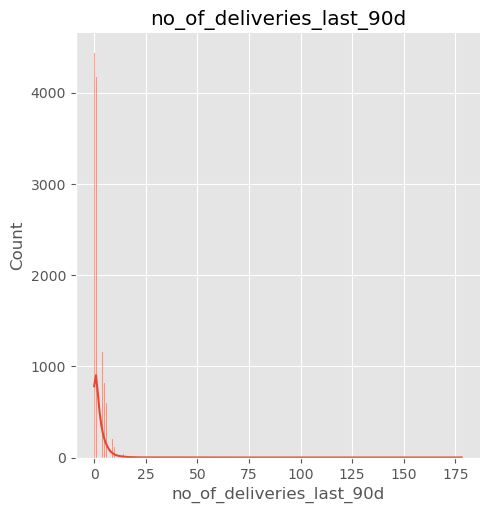

<Figure size 2000x400 with 0 Axes>

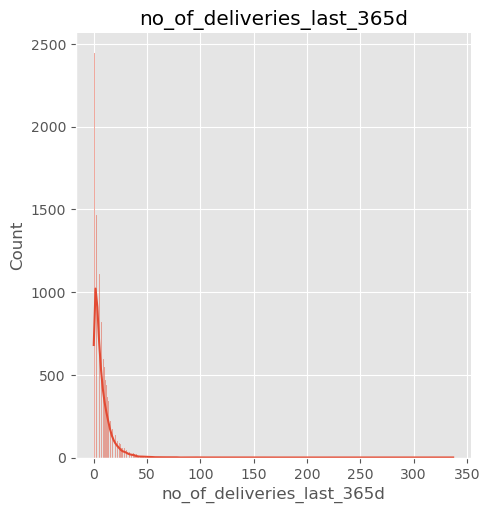

<Figure size 2000x400 with 0 Axes>

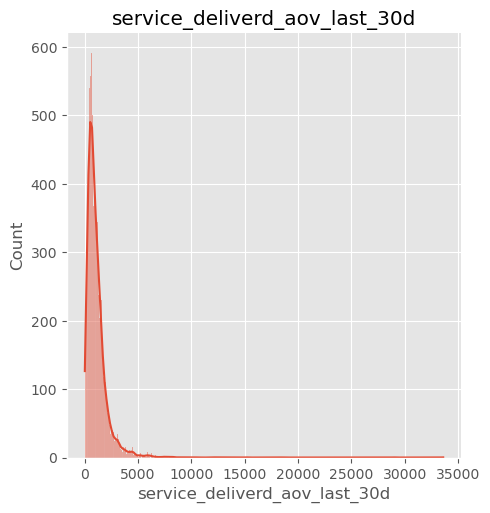

<Figure size 2000x400 with 0 Axes>

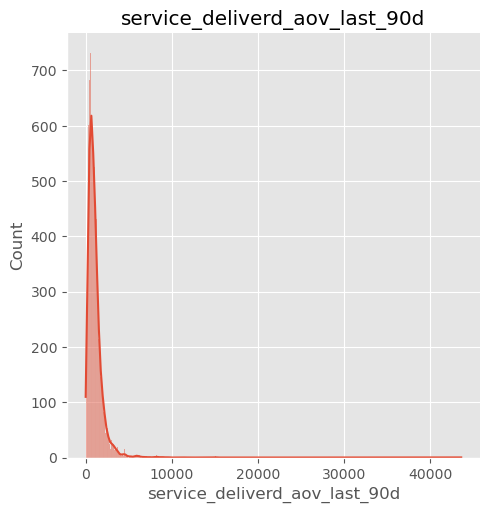

<Figure size 2000x400 with 0 Axes>

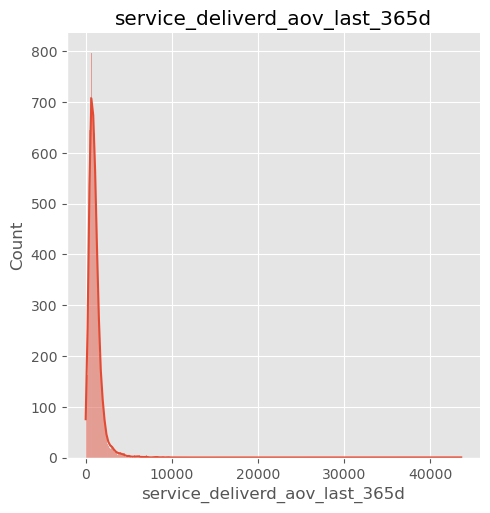

<Figure size 2000x400 with 0 Axes>

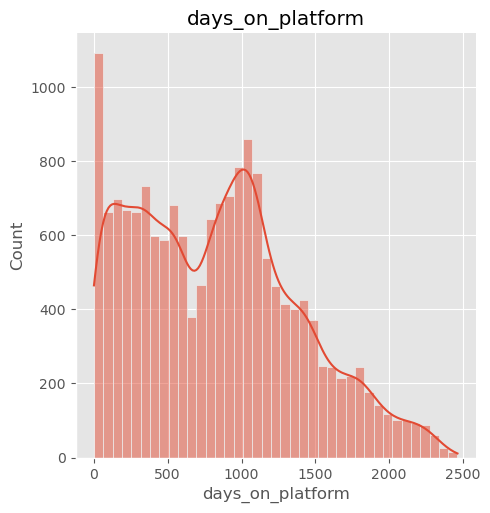

<Figure size 2000x400 with 0 Axes>

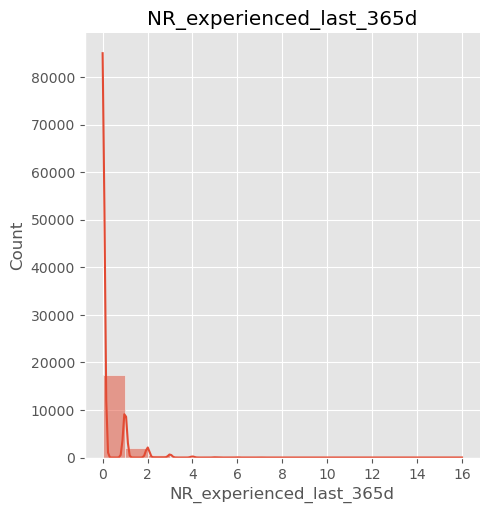

<Figure size 2000x400 with 0 Axes>

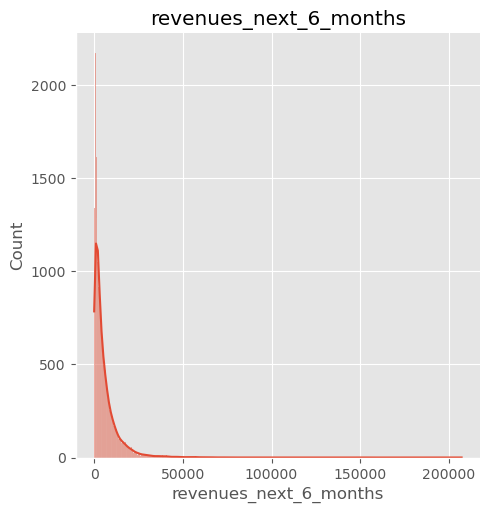

In [ ]:
# plotting histogram for each numerical variable
plt.style.use("ggplot")
num_var = df.select_dtypes(include= ["int64", "float64"]).columns

for column in num_var:
    if column not in ['Unnamed: 0']:
        plt.figure(figsize=(20,4))
        sns.displot(df[column], kde=True)
        plt.title(column)

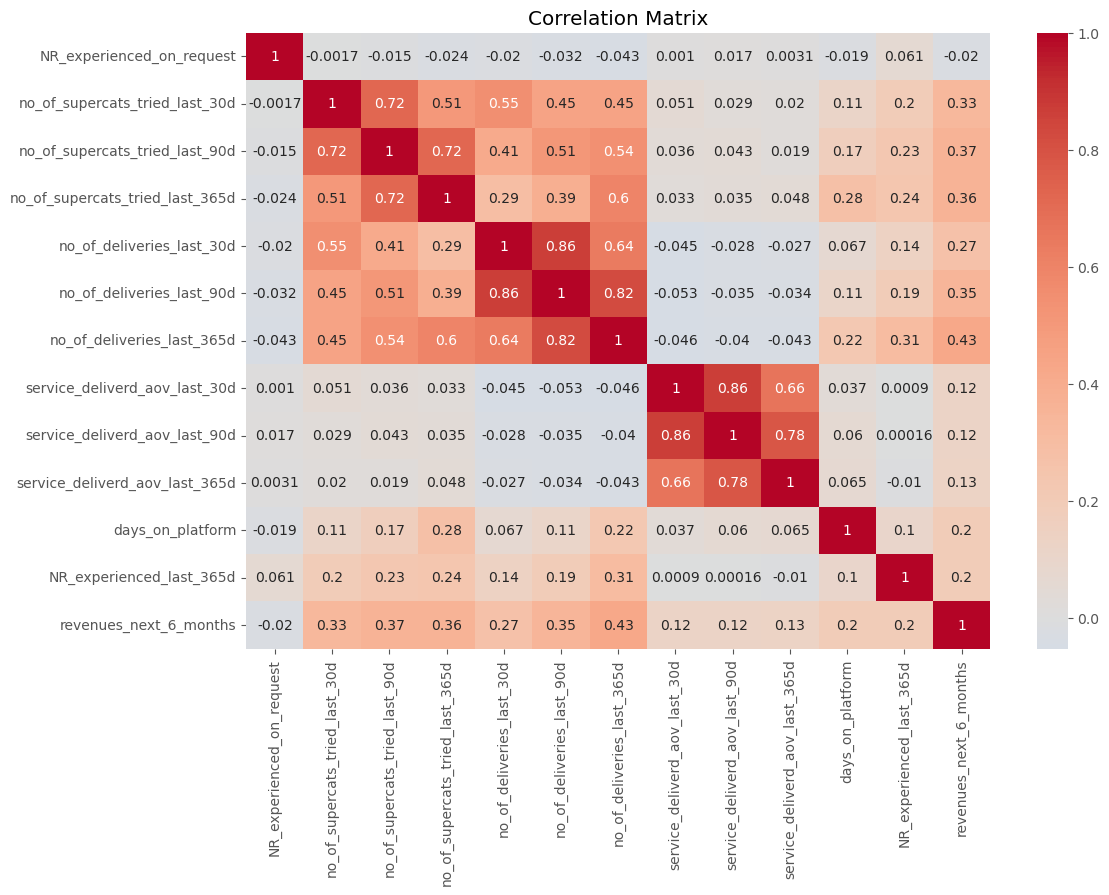

Top Correlations with NR:
NR_experienced_on_request          1.000000
NR_experienced_last_365d           0.061152
service_deliverd_aov_last_90d      0.017113
service_deliverd_aov_last_365d     0.003069
service_deliverd_aov_last_30d      0.001035
no_of_supercats_tried_last_30d    -0.001743
no_of_supercats_tried_last_90d    -0.015062
days_on_platform                  -0.018693
no_of_deliveries_last_30d         -0.019607
revenues_next_6_months            -0.020266
no_of_supercats_tried_last_365d   -0.024008
no_of_deliveries_last_90d         -0.032087
no_of_deliveries_last_365d        -0.042500
Name: NR_experienced_on_request, dtype: float64


In [17]:
# Correlation matrix (numerical features + NR)
corr_matrix = df[num_var.drop('Unnamed: 0')].corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

# Top correlations with NR
print("Top Correlations with NR:")
print(corr_matrix['NR_experienced_on_request'].sort_values(ascending=False))

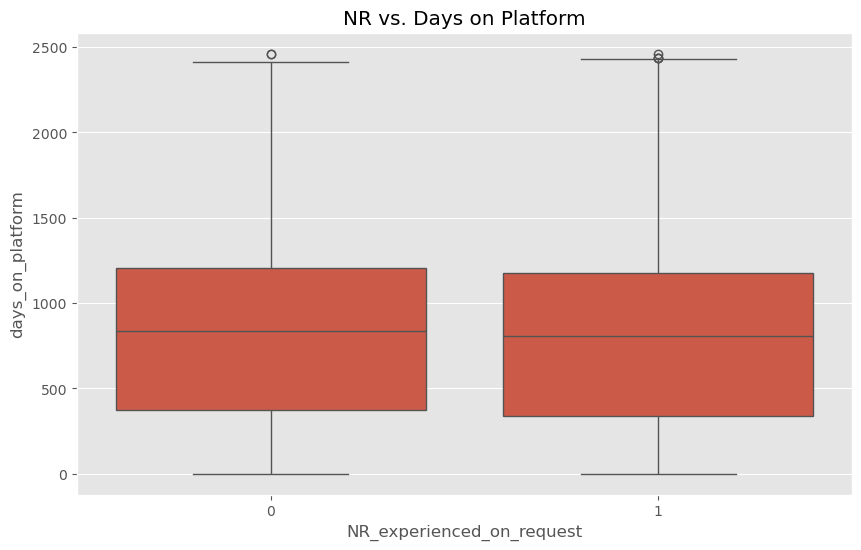

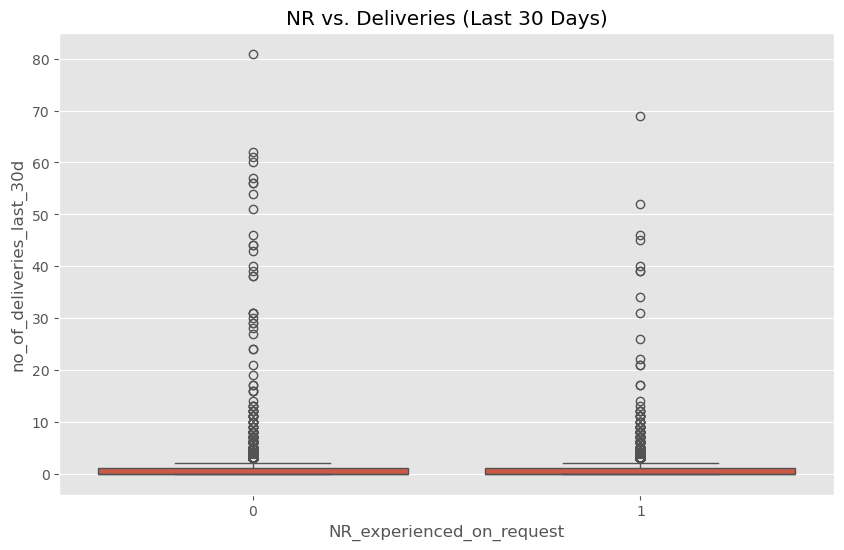

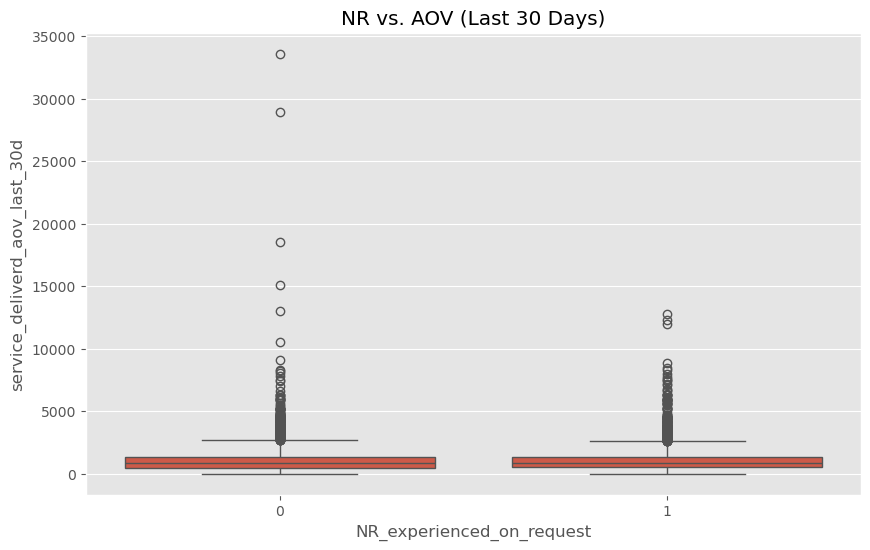

In [18]:
# NR vs. Customer Tenure
plt.figure(figsize=(10, 6))
sns.boxplot(x='NR_experienced_on_request', y='days_on_platform', data=df)
plt.title("NR vs. Days on Platform")
plt.show()

# NR vs. Delivery Frequency (last 30d)
plt.figure(figsize=(10, 6))
sns.boxplot(x='NR_experienced_on_request', y='no_of_deliveries_last_30d', data=df)
plt.title("NR vs. Deliveries (Last 30 Days)")
plt.show()

# NR vs. Average Order Value (AOV)
plt.figure(figsize=(10, 6))
sns.boxplot(x='NR_experienced_on_request', y='service_deliverd_aov_last_30d', data=df)
plt.title("NR vs. AOV (Last 30 Days)")
plt.show()

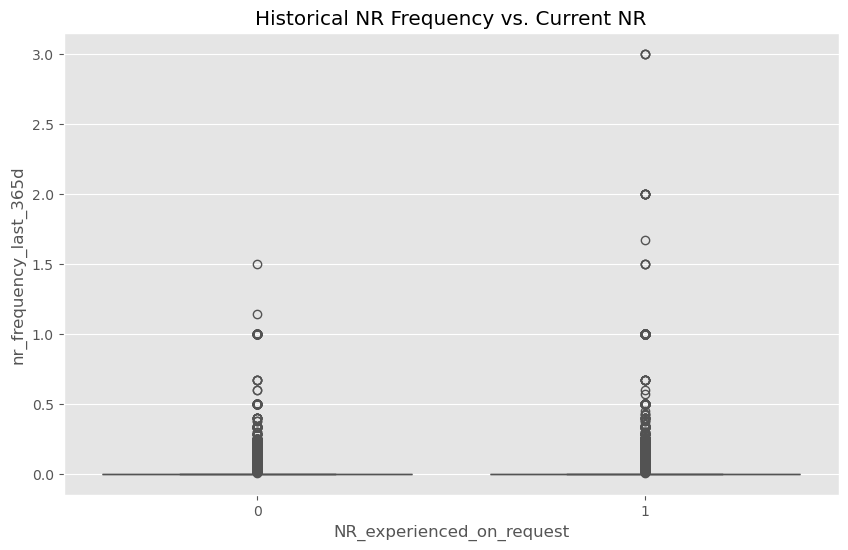

In [19]:
# Create NR frequency feature
df['nr_frequency_last_365d'] = df['NR_experienced_last_365d'] / df['no_of_deliveries_last_365d'].replace(0, 1)

# Plot NR frequency vs. NR on current request
plt.figure(figsize=(10, 6))
sns.boxplot(x='NR_experienced_on_request', y='nr_frequency_last_365d', data=df)
plt.title("Historical NR Frequency vs. Current NR")
plt.show()